In [1]:
#Imports & Paths
import os
import json
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image, ImageStat

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_ROOT  = Path('data/raw/SROIE2019')

TRAIN_IMG  = DATA_ROOT / 'train' / 'img'
TRAIN_BOX  = DATA_ROOT / 'train' / 'box'
TRAIN_ENT  = DATA_ROOT / 'train' / 'entities'

TEST_IMG   = DATA_ROOT / 'test' / 'img'
TEST_BOX   = DATA_ROOT / 'test' / 'box'
TEST_ENT   = DATA_ROOT / 'test' / 'entities'

PROC_DIR   = Path('data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

ENTITY_KEYS = ['company', 'date', 'address', 'total']

print('Setup complete!')
print(f'Train images   : {TRAIN_IMG}')
print(f'Train boxes    : {TRAIN_BOX}')
print(f'Train entities : {TRAIN_ENT}')
print(f'Processed out  : {PROC_DIR}')

Setup complete!
Train images   : data\raw\SROIE2019\train\img
Train boxes    : data\raw\SROIE2019\train\box
Train entities : data\raw\SROIE2019\train\entities
Processed out  : data\processed


In [2]:
#Verify Dataset Exists
folders = {
    'Train images'   : TRAIN_IMG,
    'Train boxes'    : TRAIN_BOX,
    'Train entities' : TRAIN_ENT,
    'Test images'    : TEST_IMG,
    'Test boxes'     : TEST_BOX,
    'Test entities'  : TEST_ENT,
}

all_ok = True
for name, path in folders.items():
    if path.exists():
        count = len(list(path.iterdir()))
        print(f'  OK      {name:20s}  {count} files')
    else:
        print(f'  MISSING {name:20s}  expected at: {path}')
        all_ok = False

print()
if all_ok:
    print('All folders found. Ready to proceed.')
else:
    print('ERROR: Fix the paths in Cell 0 before continuing.')

  OK      Train images          626 files
  OK      Train boxes           626 files
  OK      Train entities        626 files
  OK      Test images           347 files
  OK      Test boxes            347 files
  OK      Test entities         347 files

All folders found. Ready to proceed.


In [3]:
#Integrity Check
train_stems = sorted([p.stem for p in TRAIN_IMG.glob('*.jpg')])
print(f'Total train images found: {len(train_stems)}')

rows = []
for stem in train_stems:
    rows.append({
        'stem'       : stem,
        'has_image'  : (TRAIN_IMG / f'{stem}.jpg').exists(),
        'has_box'    : (TRAIN_BOX / f'{stem}.txt').exists(),
        'has_entity' : (TRAIN_ENT / f'{stem}.txt').exists(),
    })

inventory_df = pd.DataFrame(rows)

print(f'Has image file  : {inventory_df["has_image"].sum()}')
print(f'Has box file    : {inventory_df["has_box"].sum()}')
print(f'Has entity file : {inventory_df["has_entity"].sum()}')
print(f'Missing box     : {(~inventory_df["has_box"]).sum()}')
print(f'Missing entity  : {(~inventory_df["has_entity"]).sum()}')

complete_df = inventory_df[
    inventory_df['has_image'] &
    inventory_df['has_box']   &
    inventory_df['has_entity']
].copy()

GOOD_STEMS = complete_df['stem'].tolist()

print(f'\nUsable samples : {len(GOOD_STEMS)} / {len(train_stems)}')
print(f'First 5 names  : {GOOD_STEMS[:5]}')

Total train images found: 626
Has image file  : 626
Has box file    : 626
Has entity file : 626
Missing box     : 0
Missing entity  : 0

Usable samples : 626 / 626
First 5 names  : ['X00016469612', 'X00016469619', 'X00016469620', 'X00016469622', 'X00016469623']


In [4]:
#Inspect One Sample (checks entity file format)
sample = GOOD_STEMS[0]
print(f'Sample: {sample}\n')

# Load image
img = Image.open(TRAIN_IMG / f'{sample}.jpg')
print(f'Image size : {img.size}')
print(f'Image mode : {img.mode}')

# Load box file
box_text  = (TRAIN_BOX / f'{sample}.txt').read_text(encoding='utf-8', errors='replace')
box_lines = box_text.strip().split('\n')
print(f'\nBox file: {len(box_lines)} words')
print('First 3 lines:')
for line in box_lines[:3]:
    print(f'  {line}')

# Load entity file — print raw so we can see the format
raw_entity = (TRAIN_ENT / f'{sample}.txt').read_text(encoding='utf-8', errors='replace')
print(f'\nRaw entity file:')
print(raw_entity)

Sample: X00016469612

Image size : (463, 1013)
Image mode : RGB

Box file: 44 words
First 3 lines:
  72,25,326,25,326,64,72,64,TAN WOON YANN
  50,82,440,82,440,121,50,121,BOOK TA .K(TAMAN DAYA) SDN BND
  205,121,285,121,285,139,205,139,789417-W

Raw entity file:
{
    "company": "BOOK TA .K (TAMAN DAYA) SDN BHD",
    "date": "25/12/2018",
    "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",
    "total": "9.00"
}


In [5]:
#Entity File Parser
# Handles both formats:
#   Format A (JSON):      {"company": "...", "date": "...", ...}
#   Format B (key-value): company\tVALUE\ndate\tVALUE\n...

def load_entity(stem):
    """
    Load entity file for a given stem.
    Auto-detects whether it is JSON or tab-separated key:value format.
    Always returns a plain dict: {company, date, address, total}
    """
    path = TRAIN_ENT / f'{stem}.txt'
    raw  = path.read_text(encoding='utf-8', errors='replace').strip()

    # Try JSON first
    try:
        data = json.loads(raw)
        return {k: data.get(k, '') for k in ENTITY_KEYS}
    except json.JSONDecodeError:
        pass

    # Try tab-separated: COMPANY\tBOOK TA .K
    data = {}
    for line in raw.split('\n'):
        line = line.strip()
        if not line:
            continue
        if '\t' in line:
            key, _, val = line.partition('\t')
        elif ',' in line:
            key, _, val = line.partition(',')
        else:
            continue
        data[key.strip().lower()] = val.strip()

    return {k: data.get(k, '') for k in ENTITY_KEYS}

# Test it on first sample
entity = load_entity(GOOD_STEMS[0])
print('Parsed entity fields:')
for key, val in entity.items():
    print(f'  {key:10s}: {val}')

Parsed entity fields:
  company   : BOOK TA .K (TAMAN DAYA) SDN BHD
  date      : 25/12/2018
  address   : NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.
  total     : 9.00


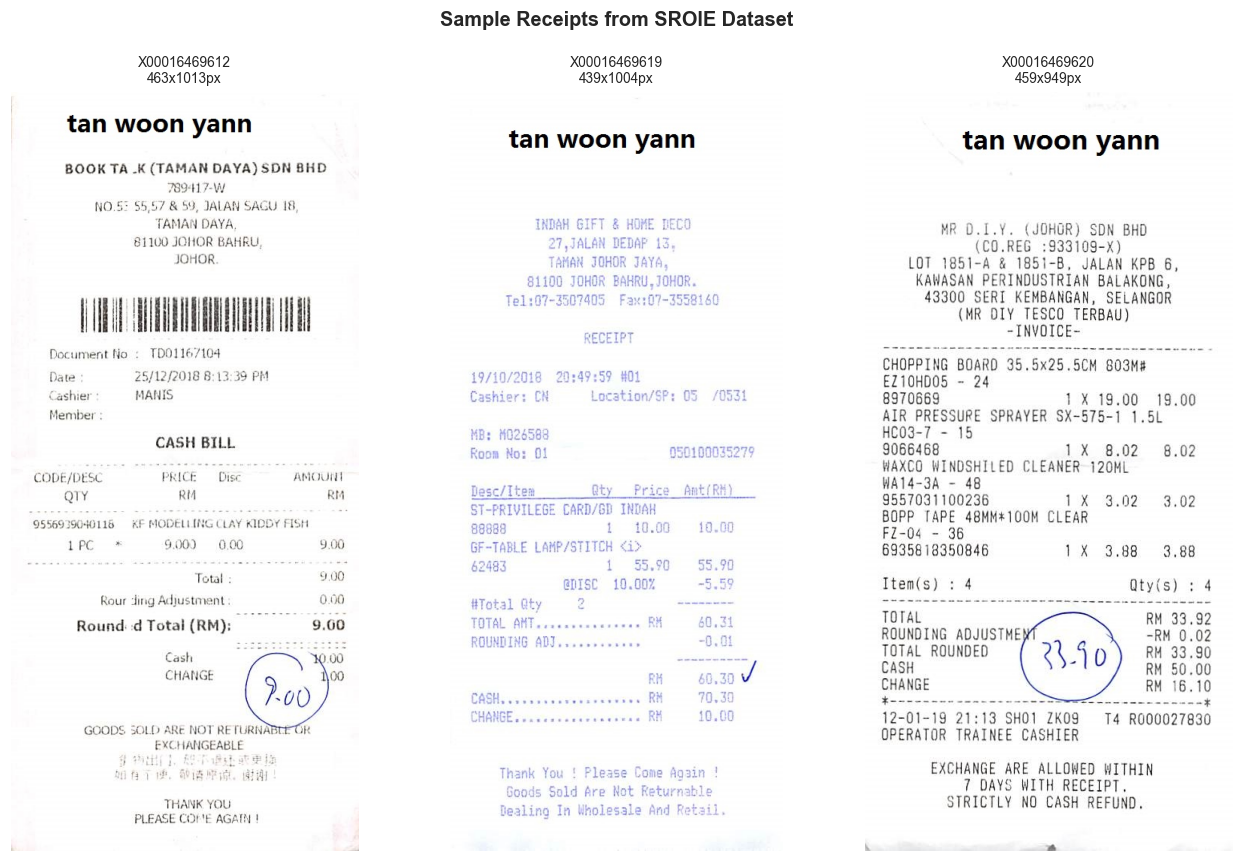

Saved: data/processed/sample_images.png


In [6]:
#Display 3 Sample Images
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
fig.suptitle('Sample Receipts from SROIE Dataset', fontsize=13, fontweight='bold')

for i, stem in enumerate(GOOD_STEMS[:3]):
    img = Image.open(TRAIN_IMG / f'{stem}.jpg')
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{stem}\n{img.size[0]}x{img.size[1]}px', fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(PROC_DIR / 'sample_images.png', bbox_inches='tight')
plt.show()
print('Saved: data/processed/sample_images.png')

In [7]:
#Image Quality Stats (~30 seconds)
def get_image_stats(stem):
    img      = Image.open(TRAIN_IMG / f'{stem}.jpg').convert('L')
    w, h     = img.size
    stat     = ImageStat.Stat(img)
    return {
        'stem'       : stem,
        'width'      : w,
        'height'     : h,
        'aspect'     : round(h / w, 2),
        'megapixels' : round(w * h / 1_000_000, 3),
        'brightness' : round(stat.mean[0], 1),
        'contrast'   : round(stat.stddev[0], 1),
    }

print('Computing image stats... (~30 seconds)')
stats_list   = [get_image_stats(s) for s in GOOD_STEMS]
img_stats_df = pd.DataFrame(stats_list)

print(f'Done! {len(img_stats_df)} images.\n')
print(img_stats_df[['width', 'height', 'megapixels', 'brightness', 'contrast']].describe().round(2))

Computing image stats... (~30 seconds)
Done! 626 images.

         width   height  megapixels  brightness  contrast
count   626.00   626.00      626.00      626.00    626.00
mean   1325.75  2355.87        5.68      235.20     39.22
std    1413.78  1841.28       11.22       18.16     13.21
min     436.00   605.00        0.28      129.30     10.30
25%     623.00  1395.50        0.93      232.22     28.50
50%     812.00  1682.50        1.43      239.40     38.40
75%     935.00  2141.00        1.94      245.78     48.10
max    4961.00  7016.00       34.81      253.80     92.30


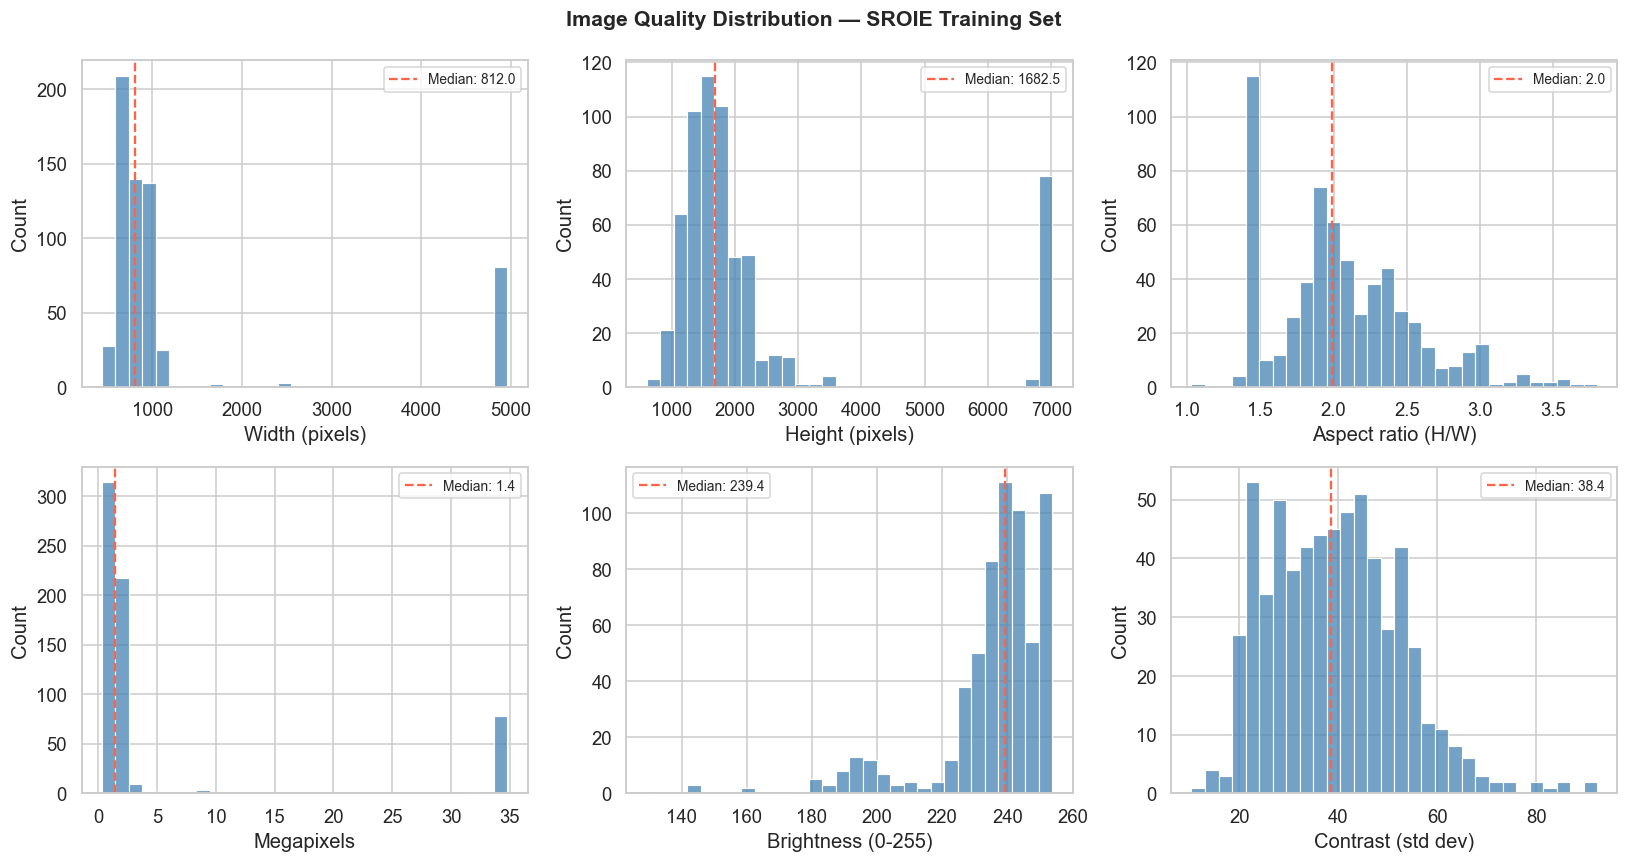

Saved: data/processed/eda_image_quality.png


In [8]:
#Image Quality Charts
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Image Quality Distribution — SROIE Training Set', fontsize=14, fontweight='bold')

metrics = [
    ('width',      'Width (pixels)',       axes[0, 0]),
    ('height',     'Height (pixels)',      axes[0, 1]),
    ('aspect',     'Aspect ratio (H/W)',   axes[0, 2]),
    ('megapixels', 'Megapixels',           axes[1, 0]),
    ('brightness', 'Brightness (0-255)',   axes[1, 1]),
    ('contrast',   'Contrast (std dev)',   axes[1, 2]),
]

for col, label, ax in metrics:
    sns.histplot(img_stats_df[col], bins=30, ax=ax, color='steelblue', edgecolor='white')
    median_val = img_stats_df[col].median()
    ax.axvline(median_val, color='tomato', linestyle='--', linewidth=1.5,
               label=f'Median: {median_val:.1f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(PROC_DIR / 'eda_image_quality.png', bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_image_quality.png')

In [9]:
#Flag Problem Images
img_stats_df['flag_dark']     = img_stats_df['brightness'] < 100
img_stats_df['flag_low_cont'] = img_stats_df['contrast']   < 40
img_stats_df['flag_tiny']     = img_stats_df['megapixels'] < 0.1
img_stats_df['any_flag']      = (
    img_stats_df['flag_dark'] |
    img_stats_df['flag_low_cont'] |
    img_stats_df['flag_tiny']
)

print('Images needing extra preprocessing in Phase 2:')
print(f'  Dark (brightness < 100) : {img_stats_df["flag_dark"].sum():4d}  ({img_stats_df["flag_dark"].mean()*100:.1f}%)')
print(f'  Low contrast (std < 40) : {img_stats_df["flag_low_cont"].sum():4d}  ({img_stats_df["flag_low_cont"].mean()*100:.1f}%)')
print(f'  Tiny (< 0.1 MP)         : {img_stats_df["flag_tiny"].sum():4d}  ({img_stats_df["flag_tiny"].mean()*100:.1f}%)')
print(f'  Any flag (total)        : {img_stats_df["any_flag"].sum():4d}  ({img_stats_df["any_flag"].mean()*100:.1f}%)')

Images needing extra preprocessing in Phase 2:
  Dark (brightness < 100) :    0  (0.0%)
  Low contrast (std < 40) :  339  (54.2%)
  Tiny (< 0.1 MP)         :    0  (0.0%)
  Any flag (total)        :  339  (54.2%)


In [10]:
#Load All Entity Files
entity_rows  = []
failed_loads = []

for stem in GOOD_STEMS:
    try:
        e   = load_entity(stem)
        row = {'stem': stem}
        for key in ENTITY_KEYS:
            val                   = e.get(key, '')
            row[key]              = val
            row[f'{key}_present'] = bool(val.strip())
            row[f'{key}_len']     = len(val)
        entity_rows.append(row)
    except Exception as ex:
        failed_loads.append((stem, str(ex)))

entity_df = pd.DataFrame(entity_rows)

print(f'Loaded : {len(entity_df)}  |  Failed : {len(failed_loads)}')
print()
entity_df[['stem', 'company', 'date', 'address', 'total']].head(3)

Loaded : 626  |  Failed : 0



,stem,company,date,address,total
0,X00016469612,BOOK TA .K (TAMAN DAYA) SDN BHD,25/12/2018,"NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...",9.00
1,X00016469619,INDAH GIFT & HOME DECO,19/10/2018,"27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...",60.30
2,X00016469620,MR D.I.Y. (JOHOR) SDN BHD,12-01-19,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",33.90


In [11]:
#Field Presence & Sample Values
print('Field presence rate:')
for key in ENTITY_KEYS:
    pct = entity_df[f'{key}_present'].mean() * 100
    bar = '#' * int(pct / 2)
    print(f'  {key:10s}: {pct:5.1f}%  {bar}')

print()
print('Average character length:')
for key in ENTITY_KEYS:
    avg = entity_df[f'{key}_len'].mean()
    mx  = entity_df[f'{key}_len'].max()
    print(f'  {key:10s}: avg={avg:.0f}  max={mx}')

print()
print('3 real examples per field:')
for key in ENTITY_KEYS:
    samples = entity_df[entity_df[f'{key}_present']][key].sample(3, random_state=42).tolist()
    print(f'  {key:10s}: {samples}')

Field presence rate:
  company   : 100.0%  ##################################################
  date      : 100.0%  ##################################################
  address   :  99.8%  #################################################
  total     :  99.8%  #################################################

Average character length:
  company   : avg=25  max=49
  date      : avg=10  max=12
  address   : avg=71  max=135
  total     : avg=5  max=8

3 real examples per field:
  company   : ['MR. D.I.Y. (M) SDN BHD', 'SANYU STATIONERY SHOP', 'SINNATHAMBY HOLDINGS SDN. BHD.']
  date      : ['27-04-18', '20/10/2017', '06/02/2018']
  address   : ['LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUSTRIAN BALAKONG, 43300 SERI KEMBANGAN, SELANGOR', 'NO. 31G&33G, JALAN SETIA INDAH X ,U13/X 40170 SETIA ALAM', 'NO 1&3, JALAN WANGSA DELIMA 12, WANGSA LINK, WANGSA MAJU, 53300 KUALA LUMPUR']
  total     : ['38.00', '8.70', '7.00']


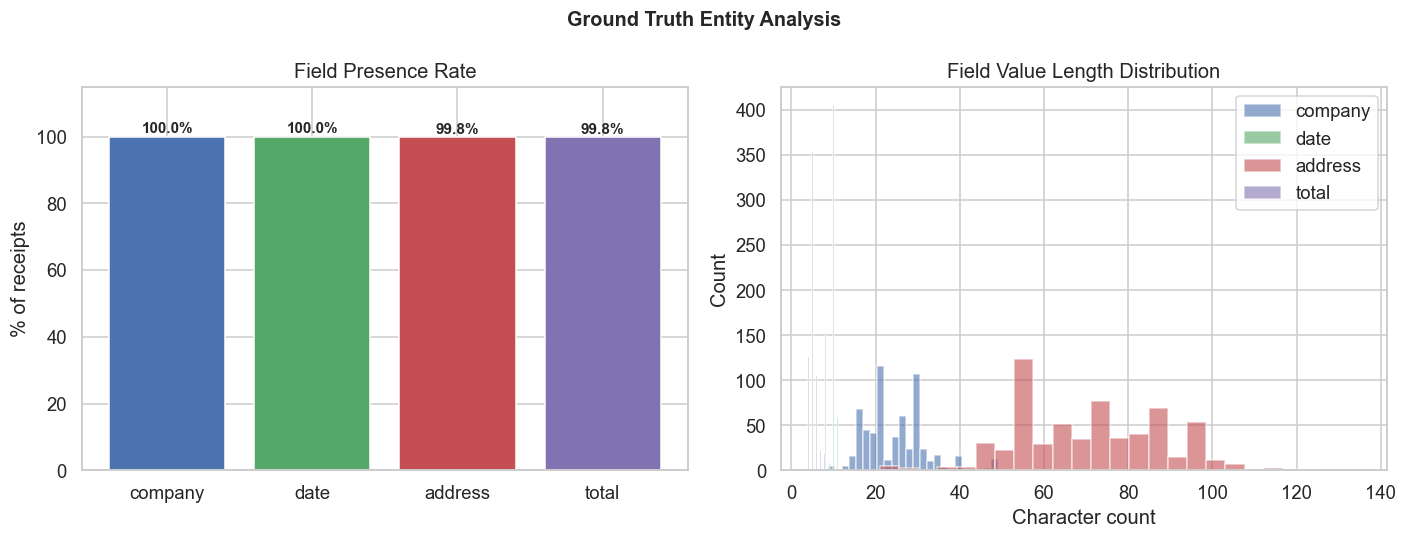

Saved: data/processed/eda_entities.png


In [12]:
#Entity Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ground Truth Entity Analysis', fontsize=13, fontweight='bold')

colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']

presence_pct = [entity_df[f'{k}_present'].mean() * 100 for k in ENTITY_KEYS]
bars = axes[0].bar(ENTITY_KEYS, presence_pct, color=colors, edgecolor='white')
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('% of receipts')
axes[0].set_title('Field Presence Rate')
for bar, val in zip(bars, presence_pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

for key, color in zip(ENTITY_KEYS, colors):
    lengths = entity_df[entity_df[f'{key}_present']][f'{key}_len']
    axes[1].hist(lengths, bins=25, alpha=0.6, label=key, color=color)
axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Count')
axes[1].set_title('Field Value Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROC_DIR / 'eda_entities.png', bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_entities.png')

In [13]:
#Total Format Analysis
def classify_total_format(val):
    if not val or not val.strip():                    return 'missing'
    val = val.strip()
    if re.match(r'^\d+\.\d{2}$', val):               return 'NNN.NN       e.g. 9.00'
    if re.match(r'^\d{1,3}(,\d{3})+\.\d{2}$', val): return 'N,NNN.NN     e.g. 1,234.56'
    if re.match(r'^[A-Z]{2,3}\s?[\d.,]+$', val):     return 'CCY+amount   e.g. MYR 9.00'
    if re.match(r'^[\d,]+$', val):                    return 'digits only  e.g. 900'
    return 'other'

entity_df['total_format'] = entity_df['total'].apply(classify_total_format)
fmt_counts = entity_df['total_format'].value_counts()

print('Total field formats:')
print(fmt_counts.to_string())
print()
print('Real examples:')
for fmt in fmt_counts.index[:5]:
    examples = entity_df[entity_df['total_format'] == fmt]['total'].dropna().head(3).tolist()
    print(f'  {fmt[:22]}: {examples}')

Total field formats:
total_format
NNN.NN       e.g. 9.00        535
CCY+amount   e.g. MYR 9.00     55
other                          34
missing                         1
N,NNN.NN     e.g. 1,234.56      1

Real examples:
  NNN.NN       e.g. 9.00: ['9.00', '60.30', '33.90']
  CCY+amount   e.g. MYR : ['RM 3.90', 'RM4.00', 'RM41.45']
  other: ['$8.20', '$8.20', '$8.20']
  missing: ['']
  N,NNN.NN     e.g. 1,23: ['1,007.50']


In [14]:
#Box Files
def parse_box_file(stem):
    """
    Read one box file. Returns list of dicts, one per word.
    Line format: x1,y1,x2,y2,x3,y3,x4,y4,TEXT
    """
    path  = TRAIN_BOX / f'{stem}.txt'
    words = []

    with open(path, encoding='utf-8', errors='replace') as f:
        for line in f:
            line  = line.strip()
            if not line:
                continue
            parts = line.split(',')
            if len(parts) < 9:
                continue
            try:
                coords = list(map(int, parts[:8]))
            except ValueError:
                continue

            text = ','.join(parts[8:]).strip()
            xs   = coords[0::2]
            ys   = coords[1::2]

            words.append({
                'stem'  : stem,
                'text'  : text,
                'x_min' : min(xs),
                'y_min' : min(ys),
                'x_max' : max(xs),
                'y_max' : max(ys),
                'width' : max(xs) - min(xs),
                'height': max(ys) - min(ys),
            })
    return words

# Test it
test_words = parse_box_file(GOOD_STEMS[0])
print(f'Words in first receipt: {len(test_words)}')
print()
print('First 5 words:')
for w in test_words[:5]:
    print(f'  "{w["text"]:20s}"  x={w["x_min"]}-{w["x_max"]}  y={w["y_min"]}-{w["y_max"]}')

Words in first receipt: 44

First 5 words:
  "TAN WOON YANN       "  x=72-326  y=25-64
  "BOOK TA .K(TAMAN DAYA) SDN BND"  x=50-440  y=82-121
  "789417-W            "  x=205-285  y=121-139
  "NO.53 55,57 & 59, JALAN SAGU 18,"  x=110-383  y=144-163
  "TAMAN DAYA,         "  x=192-299  y=169-187


In [15]:
#Bounding Box Statistics
sample_100        = GOOD_STEMS[:100]
all_words         = []
words_per_receipt = []

print('Loading 100 box files...')
for stem in sample_100:
    words = parse_box_file(stem)
    all_words.extend(words)
    words_per_receipt.append(len(words))

box_df = pd.DataFrame(all_words)

print(f'Total words (100 receipts): {len(box_df):,}')
print(f'\nWords per receipt:')
print(f'  Min    : {min(words_per_receipt)}')
print(f'  Max    : {max(words_per_receipt)}')
print(f'  Average: {sum(words_per_receipt)/len(words_per_receipt):.1f}')
print()
print(box_df[['width', 'height']].describe().round(1))

Loading 100 box files...
Total words (100 receipts): 5,244

Words per receipt:
  Min    : 18
  Max    : 119
  Average: 52.4

        width  height
count  5244.0  5244.0
mean    157.3    27.1
std     148.7    10.2
min       5.0     9.0
25%      52.0    18.0
50%     102.0    27.0
75%     210.2    34.0
max     819.0   107.0


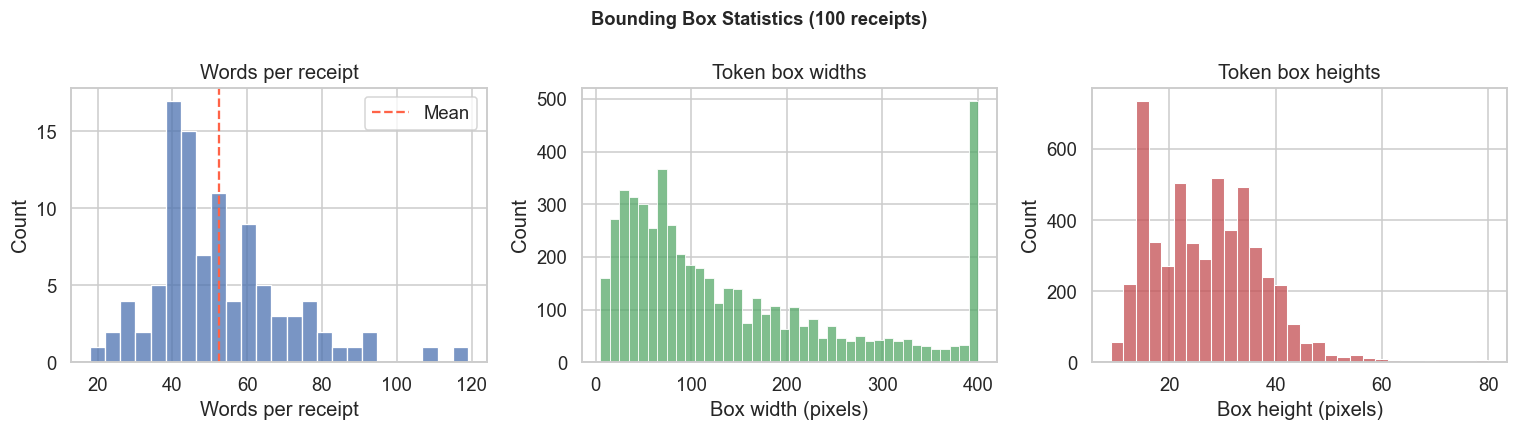

Saved: data/processed/eda_boxes.png


In [16]:
#Box Stats Charts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Bounding Box Statistics (100 receipts)', fontsize=12, fontweight='bold')

sns.histplot(words_per_receipt, bins=25, ax=axes[0], color='#4c72b0')
axes[0].axvline(sum(words_per_receipt)/len(words_per_receipt),
                color='tomato', linestyle='--', label='Mean')
axes[0].set_xlabel('Words per receipt')
axes[0].set_title('Words per receipt')
axes[0].legend()

sns.histplot(box_df['width'].clip(0, 400), bins=40, ax=axes[1], color='#55a868')
axes[1].set_xlabel('Box width (pixels)')
axes[1].set_title('Token box widths')

sns.histplot(box_df['height'].clip(0, 80), bins=30, ax=axes[2], color='#c44e52')
axes[2].set_xlabel('Box height (pixels)')
axes[2].set_title('Token box heights')

plt.tight_layout()
plt.savefig(PROC_DIR / 'eda_boxes.png', bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_boxes.png')

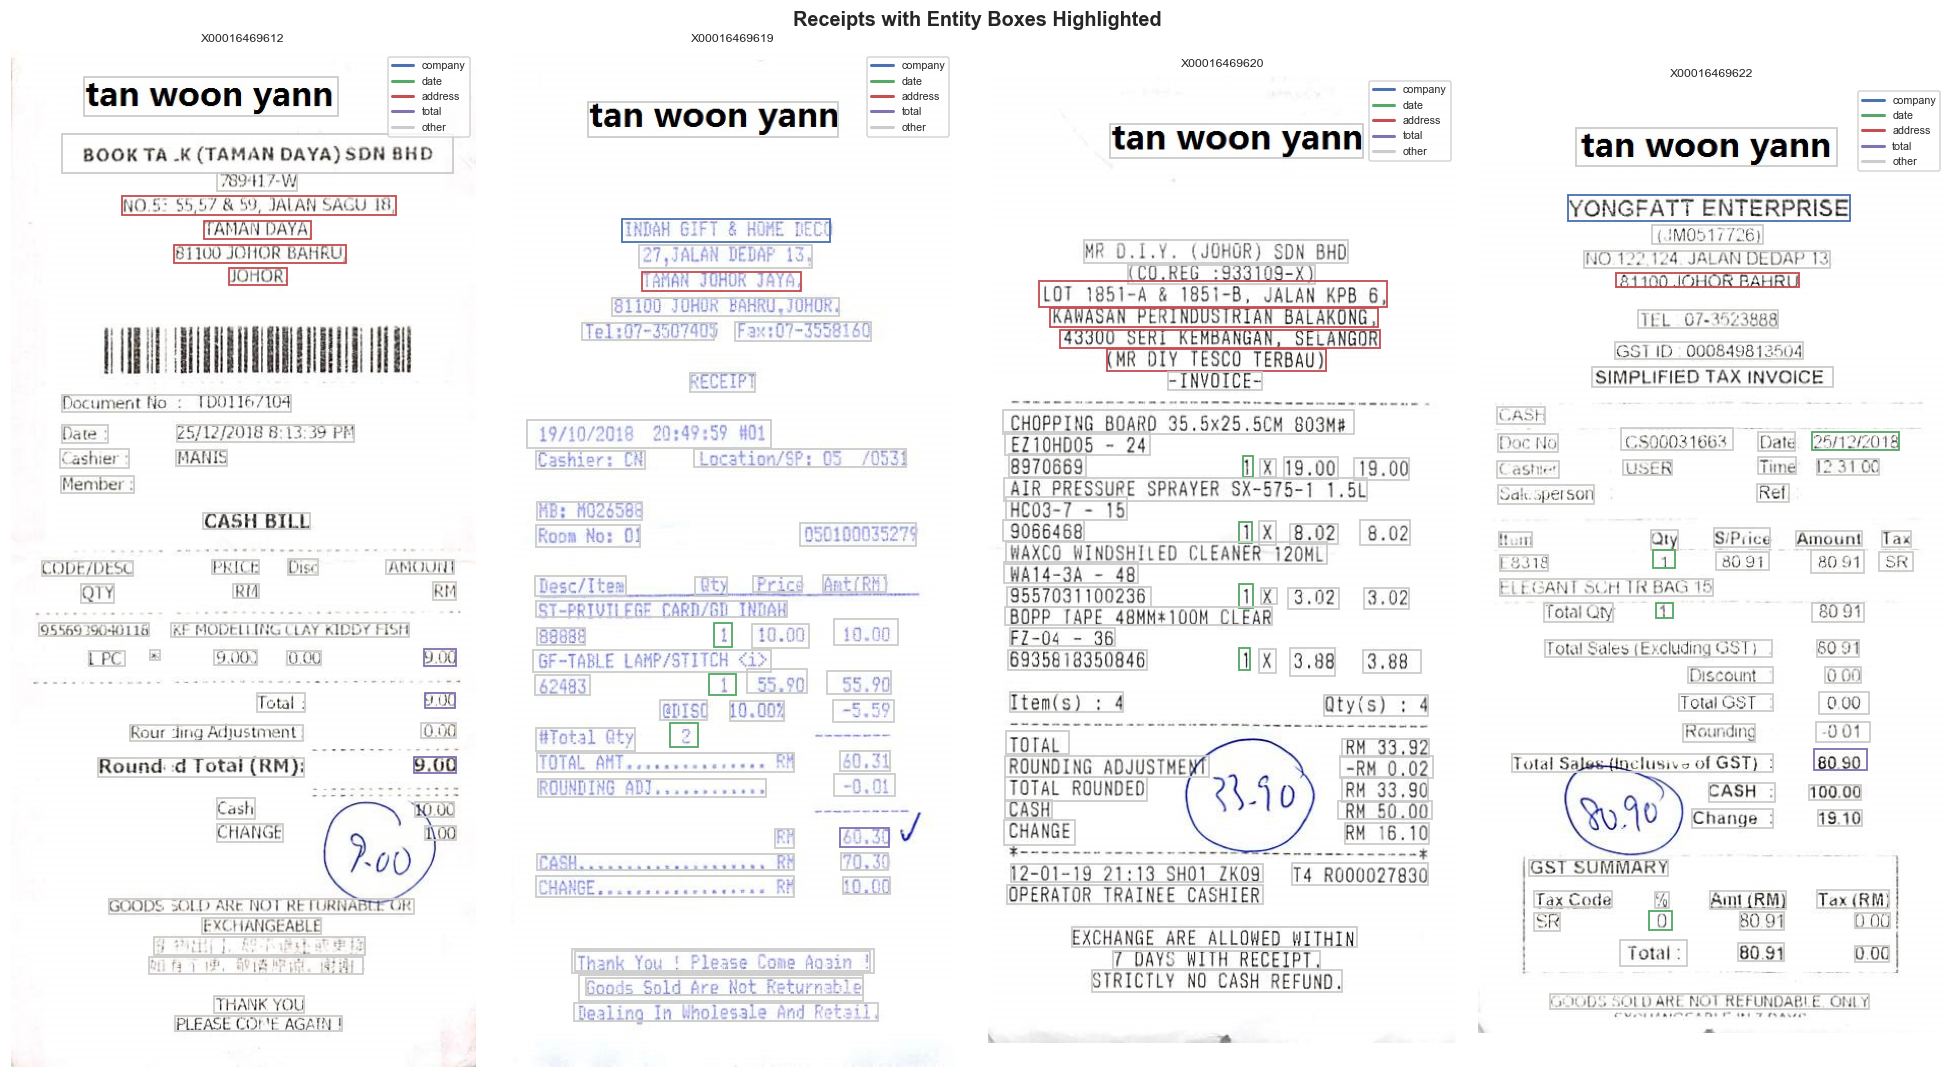

Saved: data/processed/eda_overlay.png


In [17]:
#Visual Overlay: Receipt + Entity Boxes
def get_box_color(text, entity):
    t = text.lower().strip()
    if t in entity.get('company', '').lower(): return '#4c72b0'
    if t in entity.get('date',    '').lower(): return '#55a868'
    if t in entity.get('address', '').lower(): return '#c44e52'
    if t in entity.get('total',   '').lower(): return '#8172b2'
    return '#cccccc'

def draw_receipt(stem, ax):
    img    = Image.open(TRAIN_IMG / f'{stem}.jpg')
    words  = parse_box_file(stem)
    entity = load_entity(stem)

    ax.imshow(img, cmap='gray')
    for w in words:
        color = get_box_color(w['text'], entity)
        rect  = patches.Rectangle(
            (w['x_min'], w['y_min']),
            w['width'], w['height'],
            linewidth=1.2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

    from matplotlib.lines import Line2D
    legend = [
        Line2D([0],[0], color='#4c72b0', lw=2, label='company'),
        Line2D([0],[0], color='#55a868', lw=2, label='date'),
        Line2D([0],[0], color='#c44e52', lw=2, label='address'),
        Line2D([0],[0], color='#8172b2', lw=2, label='total'),
        Line2D([0],[0], color='#cccccc', lw=2, label='other'),
    ]
    ax.legend(handles=legend, loc='upper right', fontsize=7, framealpha=0.8)
    ax.set_title(stem, fontsize=8)
    ax.axis('off')

fig, axes = plt.subplots(1, 4, figsize=(18, 10))
fig.suptitle('Receipts with Entity Boxes Highlighted', fontsize=13, fontweight='bold')
for stem, ax in zip(GOOD_STEMS[:4], axes):
    draw_receipt(stem, ax)

plt.tight_layout()
plt.savefig(PROC_DIR / 'eda_overlay.png', bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_overlay.png')

In [18]:
#Assign BIO Labels (most important cell)
# B-COMPANY = first word of company name
# I-COMPANY = continuing word of company name
# O         = not part of any entity

def assign_bio_labels(words, entity):
    entity_tokens = {}
    for key in ENTITY_KEYS:
        val = entity.get(key, '').lower()
        entity_tokens[key] = set(val.split()) if val else set()

    labelled   = []
    prev_label = 'O'

    for w in words:
        token = w['text'].lower().strip()
        label = 'O'

        for key in ENTITY_KEYS:
            if token in entity_tokens[key] and token not in {'', ',', '.', '-', ':'}:
                tag = key.upper()
                if prev_label in {f'B-{tag}', f'I-{tag}'}:
                    label = f'I-{tag}'
                else:
                    label = f'B-{tag}'
                break

        labelled.append({**w, 'label': label})
        prev_label = label

    return labelled

print('Assigning BIO labels to all receipts... (1-2 minutes)')

all_labelled = []
skipped      = 0

for stem in GOOD_STEMS:
    try:
        words  = parse_box_file(stem)
        entity = load_entity(stem)
        labelled = assign_bio_labels(words, entity)
        all_labelled.extend(labelled)
    except Exception:
        skipped += 1

corpus_df = pd.DataFrame(all_labelled)

print(f'Done!')
print(f'Total tokens : {len(corpus_df):,}')
print(f'Skipped      : {skipped}')
print()
print('Label counts:')
print(corpus_df['label'].value_counts().to_string())

Assigning BIO labels to all receipts... (1-2 minutes)
Done!
Total tokens : 33,626
Skipped      : 0

Label counts:
label
O            31992
B-TOTAL       1300
B-DATE         131
I-TOTAL         95
B-ADDRESS       78
B-COMPANY       22
I-COMPANY        4
I-ADDRESS        3
I-DATE           1


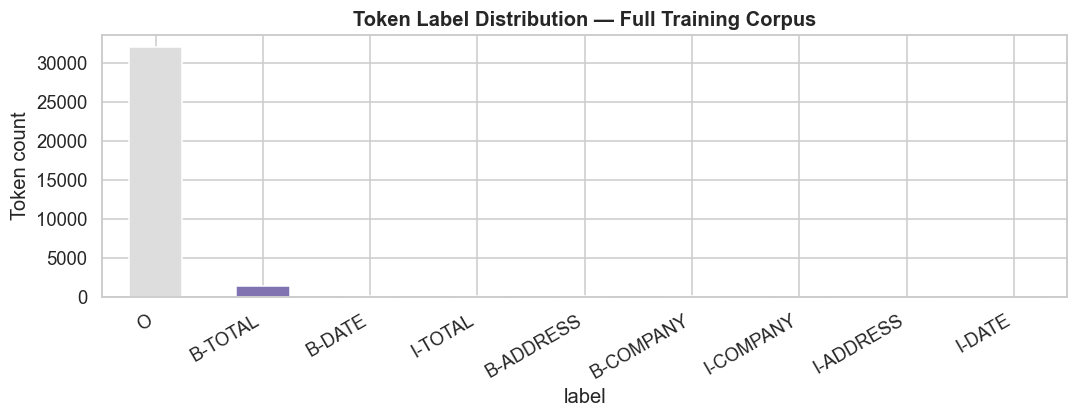

Saved: data/processed/eda_labels.png


In [19]:
#Label Distribution Chart
label_counts = corpus_df['label'].value_counts()

def label_color(label):
    if label == 'O':       return '#dddddd'
    if 'COMPANY' in label: return '#4c72b0'
    if 'DATE'    in label: return '#55a868'
    if 'ADDRESS' in label: return '#c44e52'
    if 'TOTAL'   in label: return '#8172b2'
    return '#888888'

colors = [label_color(l) for l in label_counts.index]

fig, ax = plt.subplots(figsize=(10, 4))
label_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Token Label Distribution — Full Training Corpus', fontweight='bold')
ax.set_ylabel('Token count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(PROC_DIR / 'eda_labels.png', bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_labels.png')

In [20]:
#Save All Outputs
saves = {
    'labelled_corpus.csv' : corpus_df,
    'inventory.csv'       : complete_df,
    'image_stats.csv'     : img_stats_df,
    'entity_stats.csv'    : entity_df,
}

for filename, df in saves.items():
    path = PROC_DIR / filename
    df.to_csv(path, index=False)
    kb = path.stat().st_size / 1024
    print(f'  Saved  {filename:30s}  {len(df):,} rows  {kb:.0f} KB')

print()
print('Phase 1 complete!')

  Saved  labelled_corpus.csv             33,626 rows  1722 KB
  Saved  inventory.csv                   626 rows  18 KB
  Saved  image_stats.csv                 626 rows  42 KB
  Saved  entity_stats.csv                626 rows  112 KB

Phase 1 complete!


In [21]:
#Verify labelled_corpus.csv
corpus_check = pd.read_csv('data/processed/labelled_corpus.csv')

print(f'Rows           : {len(corpus_check):,}')
print(f'Columns        : {list(corpus_check.columns)}')
print(f'Unique receipts: {corpus_check["stem"].nunique()}')
print()

first       = corpus_check[corpus_check['stem'] == GOOD_STEMS[0]]
entity_only = first[first['label'] != 'O']

print(f'First receipt: {len(first)} words total, {len(entity_only)} are entity words')
print()
print(entity_only[['text', 'label', 'x_min', 'y_min']].to_string(index=False))

Rows           : 33,626
Columns        : ['stem', 'text', 'x_min', 'y_min', 'x_max', 'y_max', 'width', 'height', 'label']
Unique receipts: 626

First receipt: 44 words total, 4 are entity words

  text     label  x_min  y_min
JOHOR. B-ADDRESS    217    216
  9.00   B-TOTAL    411    596
  9.00   B-TOTAL    401    703
  9.00   B-TOTAL    412    639


In [5]:
from src.ocr_engine import extract_tokens
from pathlib import Path

# Test Mode 1: box file (use during training)
img_path = Path('data/raw/SROIE2019/train/img') 
box_path = Path('data/raw/SROIE2019/train/box')

sample   = sorted(img_path.glob('*.jpg'))[0]
tokens   = extract_tokens(sample, box_path=box_path / f'{sample.stem}.txt')

print(f'Mode 1 — Box file: {len(tokens)} tokens')
for t in tokens[:3]:
    print(f'  {t["text"]:20s}  x_norm={t["x_norm"]}  y_norm={t["y_norm"]}')

# Test Mode 2: Tesseract on raw image
tokens2 = extract_tokens(sample)
print(f'\nMode 2 — Tesseract: {len(tokens2)} tokens')
for t in tokens2[:3]:
    print(f'  {t["text"]:20s}  conf={t["conf"]}  y_norm={t["y_norm"]}')

Mode 1 — Box file: 44 tokens
  TAN WOON YANN         x_norm=0.1555  y_norm=0.0247
  BOOK TA .K(TAMAN DAYA) SDN BND  x_norm=0.108  y_norm=0.0809
  789417-W              x_norm=0.4428  y_norm=0.1194

Mode 2 — Tesseract: 84 tokens
  |                     conf=60  y_norm=0.0197
  tan                   conf=93  y_norm=0.0316
  woon                  conf=90  y_norm=0.0365


In [4]:
import sys
sys.path.insert(0, '.')

from src.ocr_engine import extract_tokens
from src.parser import parse_fields
from pathlib import Path

img_dir = Path('data/raw/SROIE2019/train/img')
box_dir = Path('data/raw/SROIE2019/train/box')

sample = sorted(img_dir.glob('*.jpg'))[0]
box    = box_dir / f'{sample.stem}.txt'

tokens = extract_tokens(sample, box_path=box)
fields = parse_fields(tokens)

conf = fields.pop('_confidence', {})
print(f'Testing on: {sample.name}\n')
print(f'{"Field":15s}  {"Value":35s}  Confidence')
print(f'{"-"*15}  {"-"*35}  ----------')
for key, val in fields.items():
    c   = conf.get(key, 0.0)
    bar = '█' * int(c * 10)
    print(f'{key:15s}  {str(val):35s}  {c:.2f}  {bar}')

Testing on: X00016469612.jpg

Field            Value                                Confidence
---------------  -----------------------------------  ----------
company                                               0.00  
date             25/12/2018                           0.95  █████████
address                                               0.00  
total            9.00                                 0.98  █████████
tax                                                   0.00  
tax_rate                                              0.00  
invoice_number   TD01167104                           0.90  █████████
currency         RM                                   0.90  █████████
email                                                 0.00  
phone                                                 0.00  


In [7]:
corpus_df = pd.read_csv('data/processed/labelled_corpus.csv')
print(corpus_df['label'].value_counts())
print()

# Check how many B-TOTAL tokens per receipt on average
total_per_receipt = corpus_df[corpus_df['label'] == 'B-TOTAL'].groupby('stem').size()
print('B-TOTAL tokens per receipt:')
print(total_per_receipt.describe())
print()
print('Receipts with more than 1 B-TOTAL:', (total_per_receipt > 1).sum())

label
O            31992
B-TOTAL       1300
B-DATE         131
I-TOTAL         95
B-ADDRESS       78
B-COMPANY       22
I-COMPANY        4
I-ADDRESS        3
I-DATE           1
Name: count, dtype: int64

B-TOTAL tokens per receipt:
count    574.000000
mean       2.264808
std        1.260038
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        6.000000
dtype: float64

Receipts with more than 1 B-TOTAL: 358


In [2]:
#imports

import sys, os, tempfile
sys.path.insert(0, '.')

import pandas as pd
import pycrfsuite
from pathlib import Path
from src.model import (
    corpus_to_sequences, build_features,
    train_crf, save_model, load_model,
    predict, extract_entities, evaluate, top_features
)

In [3]:
import json, re
from pathlib import Path

DATA_ROOT   = Path('data/raw/SROIE2019')
TRAIN_IMG   = DATA_ROOT / 'train' / 'img'
TRAIN_BOX   = DATA_ROOT / 'train' / 'box'
TRAIN_ENT   = DATA_ROOT / 'train' / 'entities'
PROC_DIR    = Path('data/processed')
ENTITY_KEYS = ['company', 'date', 'address', 'total']

TOTAL_KEYWORDS = {'total', 'amount', 'jumlah', 'balance', 'due',
                  'payable', 'subtotal', 'grand', 'net', 'bil'}
CASH_KEYWORDS  = {'cash', 'change', 'tender', 'void', 'refund'}

def load_entity(stem):
    path = TRAIN_ENT / f'{stem}.txt'
    raw  = path.read_text(encoding='utf-8', errors='replace').strip()
    try:
        data = json.loads(raw)
        return {k: data.get(k, '') for k in ENTITY_KEYS}
    except json.JSONDecodeError:
        data = {}
        for line in raw.split('\n'):
            line = line.strip()
            if not line: continue
            if '\t' in line:  key, _, val = line.partition('\t')
            elif ',' in line: key, _, val = line.partition(',')
            else: continue
            data[key.strip().lower()] = val.strip()
        return {k: data.get(k, '') for k in ENTITY_KEYS}

def parse_box_file(stem):
    words = []
    with open(TRAIN_BOX / f'{stem}.txt', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split(',')
            if len(parts) < 9: continue
            try:    coords = list(map(int, parts[:8]))
            except: continue
            text = ','.join(parts[8:]).strip()
            xs = coords[0::2]; ys = coords[1::2]
            words.append({
                'text'  : text,
                'x_min' : min(xs), 'y_min': min(ys),
                'x_max' : max(xs), 'y_max': max(ys),
                'width' : max(xs) - min(xs),
                'height': max(ys) - min(ys),
            })
    return words

def normalise_amount(val):
    val = re.sub(r'(?i)(rm|myr|usd|sgd|gbp|eur|inr|\$|£|€|₹)', '', val)
    try:    return str(round(float(val.strip().replace(',', '')), 2))
    except: return val.strip()

def token_matches_entity(token_text, entity_val, key):
    if not entity_val or not token_text:
        return False
    t = token_text.strip()
    e = entity_val.strip()
    if key == 'total':
        return normalise_amount(t) == normalise_amount(e)
    t_l = t.lower(); e_l = e.lower()
    if key == 'date':    return e_l in t_l or t_l == e_l
    if key == 'company': return t_l in e_l or e_l in t_l
    if key == 'address': return t_l in e_l or e_l in t_l
    return False

def find_best_total_idx(words, entity):
    """
    Find the index of the correct total token.

    Strategy (in priority order):
    1. Find TOTAL keyword, then look for matching amount in the
       next 5 tokens — this handles columnar receipts where
       TOTAL label and value are separate tokens
    2. If multiple TOTAL keywords exist, use the last one
    3. Fall back to last matching amount before any CASH amount
    4. Fall back to first matching amount
    """
    gt_total  = entity.get('total', '').strip()
    gt_norm   = normalise_amount(gt_total)
    if not gt_norm:
        return -1

    n = len(words)

    # Find all TOTAL keyword positions (last one is most likely the real total)
    total_kw_positions = [i for i, w in enumerate(words)
                          if w['text'].lower().strip() == 'total']

    # Strategy 1: look immediately after TOTAL keyword for matching amount
    # Use last TOTAL keyword since that's the grand total row
    for kw_idx in reversed(total_kw_positions):
        for j in range(kw_idx + 1, min(n, kw_idx + 8)):
            if normalise_amount(words[j]['text']) == gt_norm:
                return j

    # Strategy 2: broader TOTAL_KEYWORDS search
    other_kw_positions = [i for i, w in enumerate(words)
                          if w['text'].lower().strip() in TOTAL_KEYWORDS
                          and w['text'].lower().strip() != 'total']
    for kw_idx in reversed(other_kw_positions):
        for j in range(kw_idx + 1, min(n, kw_idx + 8)):
            if normalise_amount(words[j]['text']) == gt_norm:
                return j

    # Strategy 3: find all matching candidates, pick last one
    # that is NOT followed by another matching amount within 3 tokens
    # (the real total is typically the last occurrence)
    all_candidates = [i for i, w in enumerate(words)
                      if normalise_amount(w['text']) == gt_norm]

    if not all_candidates:
        return -1

    if len(all_candidates) == 1:
        return all_candidates[0]

    # Find cash/change positions to understand receipt structure
    cash_positions = [i for i, w in enumerate(words)
                      if w['text'].lower().strip() in CASH_KEYWORDS]

    # If CASH appears as a LABEL (before the values section),
    # the total is after the last TOTAL keyword
    # If CASH appears as a VALUE (after total), total is before CASH
    if cash_positions and total_kw_positions:
        last_total_kw = max(total_kw_positions)
        last_cash     = max(cash_positions)

        if last_total_kw < last_cash:
            # Normal receipt: TOTAL keyword then values, CASH is a value after
            # Pick last candidate before the cash value
            before_cash = [i for i in all_candidates if i < last_cash]
            if before_cash:
                return max(before_cash)
        else:
            # Columnar receipt: CASH is a label, total value comes after
            # Pick first candidate after the last total keyword
            after_kw = [i for i in all_candidates if i > last_total_kw]
            if after_kw:
                return min(after_kw)

    # Default: return last candidate
    return all_candidates[-1]


def assign_bio_labels_final(words, entity):
    """Final BIO labelling with improved total detection."""

    best_total_idx   = find_best_total_idx(words, entity)
    date_labelled    = False
    company_labelled = False
    labelled         = []
    prev_label       = 'O'

    for idx, w in enumerate(words):
        label = 'O'

        if idx == best_total_idx:
            label = 'B-TOTAL'

        elif not date_labelled and token_matches_entity(
                w['text'], entity.get('date', ''), 'date'):
            label         = 'B-DATE'
            date_labelled = True

        elif not company_labelled and entity.get('company', '') and \
                token_matches_entity(w['text'], entity.get('company',''), 'company'):
            label             = 'B-COMPANY'
            company_labelled  = True

        elif entity.get('address', '') and \
                token_matches_entity(w['text'], entity.get('address',''), 'address'):
            tag   = 'ADDRESS'
            label = f'I-{tag}' if prev_label in {f'B-{tag}', f'I-{tag}'} else f'B-{tag}'

        labelled.append({**w, 'label': label})
        prev_label = label

    return labelled


# ── Rebuild ───────────────────────────────────────────────────────────────────
stems    = sorted([p.stem for p in TRAIN_IMG.glob('*.jpg')])
complete = [s for s in stems
            if (TRAIN_IMG / f'{s}.jpg').exists()
            and (TRAIN_BOX / f'{s}.txt').exists()
            and (TRAIN_ENT / f'{s}.txt').exists()]

print(f'Rebuilding for {len(complete)} receipts...')
all_rows = []
skipped  = 0

for stem in complete:
    try:
        words    = parse_box_file(stem)
        entity   = load_entity(stem)
        labelled = assign_bio_labels_final(words, entity)
        img_w    = max((w['x_max'] for w in words), default=1)
        img_h    = max((w['y_max'] for w in words), default=1)
        for item in labelled:
            item['stem']          = stem
            item['x_norm']        = round(item['x_min'] / img_w, 4)
            item['y_norm']        = round(item['y_min'] / img_h, 4)
            item['x_center_norm'] = round((item['x_min']+item['x_max'])/2/img_w, 4)
            item['y_center_norm'] = round((item['y_min']+item['y_max'])/2/img_h, 4)
            item['width_norm']    = round(item['width']  / img_w, 4)
            item['height_norm']   = round(item['height'] / img_h, 4)
        all_rows.extend(labelled)
    except Exception as e:
        skipped += 1

corpus_df = pd.DataFrame(all_rows)
corpus_df.to_csv(PROC_DIR / 'labelled_corpus.csv', index=False)

print(f'Done! {len(corpus_df):,} tokens  |  skipped: {skipped}')
print()
print('Label distribution:')
print(corpus_df['label'].value_counts().to_string())
print()

# Verify problem receipts
print('Verifying problem receipts:')
for stem in ['X51007339639', 'X51007339642', 'X51007339650']:
    sample    = corpus_df[corpus_df['stem'] == stem]
    total_row = sample[sample['label'] == 'B-TOTAL']
    if len(total_row) > 0:
        pos  = total_row.index[0] - sample.index[0]
        text = total_row['text'].values[0]
        print(f'  {stem}: B-TOTAL at position {pos} -> "{text}"  ✓')
    else:
        print(f'  {stem}: NO B-TOTAL FOUND  ✗')

Rebuilding for 626 receipts...
Done! 33,626 tokens  |  skipped: 0

Label distribution:
label
O            28544
B-ADDRESS     1739
I-ADDRESS     1485
B-DATE         622
B-TOTAL        622
B-COMPANY      614

Verifying problem receipts:
  X51007339639: B-TOTAL at position 34 -> "4.00"  ✓
  X51007339642: B-TOTAL at position 33 -> "14.00"  ✓
  X51007339650: B-TOTAL at position 33 -> "24.00"  ✓


In [4]:
#train/test split

corpus_df = pd.read_csv('data/processed/labelled_corpus.csv')

stems    = corpus_df['stem'].unique()
n_train  = int(len(stems) * 0.8)
train_df = corpus_df[corpus_df['stem'].isin(stems[:n_train])]
test_df  = corpus_df[corpus_df['stem'].isin(stems[n_train:])]

print(f'Total receipts : {len(stems)}')
print(f'Train          : {len(stems[:n_train])} receipts  {len(train_df):,} tokens')
print(f'Test           : {len(stems[n_train:])} receipts  {len(test_df):,} tokens')

Total receipts : 626
Train          : 500 receipts  27,067 tokens
Test           : 126 receipts  6,559 tokens


In [5]:
Path('models').mkdir(exist_ok=True)

tagger = train_crf(train_df, c1=0.01, c2=0.10, max_iter=300, verbose=False)
save_model(tagger, 'models/crf_model.pkl')

Preparing training sequences...
  Receipts : 500
  Tokens   : 27,067
  Labels   : {'O': 22998, 'B-ADDRESS': 1387, 'I-ADDRESS': 1201, 'B-DATE': 497, 'B-TOTAL': 496, 'B-COMPANY': 488}

Training CRF (c1=0.01, c2=0.1, max_iter=300)...
Training complete.
Saved: models/crf_model.crfsuite  (2562 KB)


In [6]:
results = evaluate(tagger, test_df)
print(results.to_string(index=False))

             label  precision  recall    f1  support
         B-ADDRESS      0.820   0.787 0.803      352
         B-COMPANY      0.951   0.929 0.940      126
            B-DATE      0.875   0.896 0.885      125
           B-TOTAL      0.596   0.468 0.524      126
         I-ADDRESS      0.858   0.746 0.798      284
         micro avg      0.831   0.767 0.798     1013
OVERALL (weighted)      0.826   0.767 0.794     1013


In [7]:
#test on one sample

from src.ocr_engine import extract_tokens
from src.parser import parse_fields

sample_img = sorted(TRAIN_IMG.glob('*.jpg'))[0]
sample_box = TRAIN_BOX / f'{sample_img.stem}.txt'

# Get tokens
tokens = extract_tokens(sample_img, box_path=sample_box)

# CRF prediction
predicted = predict(tagger, tokens)
entities  = extract_entities(predicted)

# Parser fields
parser_fields = parse_fields(tokens)

print(f'Receipt: {sample_img.name}')
print()
print('CRF entities:')
conf = entities.pop('_crf_confidence', {})
for key, val in entities.items():
    c = conf.get(key, 0.0)
    print(f'  {key:10s}: {val:35s}  conf={c:.2f}')

print()
print('Parser fields:')
pconf = parser_fields.pop('_confidence', {})
for key, val in parser_fields.items():
    if val:
        c = pconf.get(key, 0.0)
        print(f'  {key:15s}: {val:35s}  conf={c:.2f}')

Receipt: X00016469612.jpg

CRF entities:
  company   :                                      conf=0.00
  date      : 25/12/2018 8:13:39 PM                conf=0.98
  address   : NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.  conf=0.99
  total     : 9.00                                 conf=0.82

Parser fields:
  invoice_number : TD01167104                           conf=0.92
  date           : 25/12/2018                           conf=0.95
  vendor_name    : TAN WOON YANN BOOK TA .K(TAMAN DAYA) SDN BND 789417-W NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU,  conf=0.45
  total          : 9.00                                 conf=0.98
  currency       : RM                                   conf=0.90


In [8]:
#crf + parser merge

def merge_results(crf_entities, parser_fields):
    """
    CRF fills: company, address
    Parser fills: date, total, tax, invoice_number, email, phone, currency
    Best confidence wins for overlapping fields.
    """
    crf_conf    = crf_entities.pop('_crf_confidence', {})
    parser_conf = parser_fields.pop('_confidence', {})

    merged = {}
    all_keys = set(list(crf_entities.keys()) + list(parser_fields.keys()))

    for key in all_keys:
        crf_val    = crf_entities.get(key, '')
        parser_val = parser_fields.get(key, '')
        crf_c      = crf_conf.get(key, 0.0)
        parser_c   = parser_conf.get(key, 0.0)

        if crf_val and parser_val:
            merged[key] = crf_val if crf_c >= parser_c else parser_val
        elif crf_val:
            merged[key] = crf_val
        elif parser_val:
            merged[key] = parser_val
        else:
            merged[key] = ''

    return merged

# Test merge
crf_out    = extract_entities(predict(tagger, tokens))
parser_out = parse_fields(tokens)
final      = merge_results(crf_out, parser_out)

print('Final merged output:')
for key, val in final.items():
    if val:
        print(f'  {key:15s}: {val}')

Final merged output:
  total          : 9.00
  currency       : RM
  date           : 25/12/2018 8:13:39 PM
  address        : NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.
  vendor_name    : TAN WOON YANN BOOK TA .K(TAMAN DAYA) SDN BND 789417-W NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU,
  invoice_number : TD01167104


In [9]:
import sys, os, tempfile, re, pickle
sys.path.insert(0, '.')
import pandas as pd
import pycrfsuite
from pathlib import Path
from src.model import save_model, evaluate

corpus_df = pd.read_csv('data/processed/labelled_corpus.csv')

TOTAL_KEYWORDS   = {'total', 'amount', 'jumlah', 'balance', 'due',
                    'payable', 'subtotal', 'grand', 'net', 'bil'}
DATE_KEYWORDS    = {'date', 'tarikh', 'dated', 'invoice', 'issued'}
ADDRESS_KEYWORDS = {'address', 'addr', 'no.', 'jalan', 'street', 'road',
                    'avenue', 'lane', 'taman', 'lorong'}
COMPANY_SUFFIXES = {'sdn', 'bhd', 'ltd', 'llc', 'inc', 'corp',
                    'pty', 'plc', 'pte', 'gmbh', 'berhad'}
SKIP_KEYWORDS    = {'cash', 'change', 'tender', 'rounding', 'round',
                    'disc', 'discount', 'deposit', 'payment', 'paid'}

def _bin(v, n): 
    return min(int(v * n), n - 1)

def _near(tokens, i, kws, window=4):
    for j in range(max(0, i-window), min(len(tokens), i+window+1)):
        if j != i and tokens[j]['text'].lower().strip() in kws:
            return True
    return False

def _near_skip(tokens, i, window=3):
    """Check if a skip keyword (CASH, CHANGE) is near this token."""
    return _near(tokens, i, SKIP_KEYWORDS, window)

def _prev_is_total_kw(tokens, i, window=5):
    """Check if a TOTAL keyword appears BEFORE this token (within window)."""
    for j in range(max(0, i-window), i):
        if tokens[j]['text'].lower().strip() in TOTAL_KEYWORDS:
            return True
    return False

def _next_is_total_kw(tokens, i, window=3):
    """Check if a TOTAL keyword appears AFTER this token (within window)."""
    for j in range(i+1, min(len(tokens), i+window+1)):
        if tokens[j]['text'].lower().strip() in TOTAL_KEYWORDS:
            return True
    return False

def word_features(tokens, i):
    t      = tokens[i]
    text   = t['text'].strip()
    text_l = text.lower()
    x      = t.get('x_norm', 0.5)
    y      = t.get('y_norm', 0.5)

    # Is this token a pure decimal amount?
    is_amount = bool(re.match(r'^\$?[\d,]+\.\d{2}$', text))
    is_int    = bool(re.match(r'^\d+$', text))

    feats = [
        'bias',
        f'word={text_l}',
        f'word_len={len(text)}',
        f'prefix2={text_l[:2]}',
        f'prefix3={text_l[:3]}',
        f'suffix2={text_l[-2:]}',
        f'suffix3={text_l[-3:]}',
        f'is_upper={text.isupper()}',
        f'is_digit={text.isdigit()}',
        f'is_alnum={text.isalnum()}',
        f'has_digit={any(c.isdigit() for c in text)}',
        f'has_special={any(not c.isalnum() and c!=" " for c in text)}',
        f'is_amount={is_amount}',
        f'is_int={is_int}',
        f'has_currency={any(c in text for c in ["$","£","€","₹","RM"])}',
        f'is_company_suffix={text_l in COMPANY_SUFFIXES}',
        f'is_total_kw={text_l in TOTAL_KEYWORDS}',
        f'is_date_kw={text_l in DATE_KEYWORDS}',
        f'is_skip_kw={text_l in SKIP_KEYWORDS}',
        f'like_date={bool(re.match(r".*\d{1,2}[\/\-\.]\d{1,2}[\/\-\.]\d{2,4}.*", text))}',

        # Position
        f'x_bin={_bin(x, 5)}',
        f'y_bin={_bin(y, 10)}',
        f'in_top_20={y < 0.20}',
        f'in_top_40={y < 0.40}',
        f'in_bottom_30={y > 0.70}',
        f'in_bottom_20={y > 0.80}',
        f'on_right={x > 0.55}',
        f'on_far_right={x > 0.75}',
        f'on_left={x < 0.30}',

        # Keyword proximity
        f'near_total={_near(tokens, i, TOTAL_KEYWORDS)}',
        f'near_date={_near(tokens, i, DATE_KEYWORDS)}',
        f'near_address={_near(tokens, i, ADDRESS_KEYWORDS)}',
        f'near_suffix={_near(tokens, i, COMPANY_SUFFIXES)}',

        # TOTAL-specific features — the key improvements
        f'prev_is_total_kw={_prev_is_total_kw(tokens, i, window=5)}',
        f'next_is_total_kw={_next_is_total_kw(tokens, i, window=3)}',
        f'near_skip_kw={_near_skip(tokens, i, window=3)}',
        f'amount_on_right={is_amount and x > 0.55}',
        f'amount_in_bottom={is_amount and y > 0.60}',
        f'amount_near_total={is_amount and _near(tokens, i, TOTAL_KEYWORDS, 6)}',
        f'amount_not_near_skip={is_amount and not _near_skip(tokens, i, 4)}',
    ]

    # Previous token
    if i > 0:
        pt   = tokens[i-1]
        pt_l = pt['text'].lower().strip()
        feats += [
            f'prev={pt_l}',
            f'prev_is_upper={pt["text"].isupper()}',
            f'prev_is_digit={pt["text"].isdigit()}',
            f'prev_is_total_kw2={pt_l in TOTAL_KEYWORDS}',
            f'prev_is_suffix={pt_l in COMPANY_SUFFIXES}',
            f'prev_is_skip={pt_l in SKIP_KEYWORDS}',
            f'prev_is_amount={bool(re.match(r"^\$?[\d,]+\.\d{2}$", pt["text"]))}',
        ]
    else:
        feats.append('BOS')

    if i > 1:
        ppt_l = tokens[i-2]['text'].lower().strip()
        feats += [
            f'prev2={ppt_l}',
            f'prev2_is_total_kw={ppt_l in TOTAL_KEYWORDS}',
            f'prev2_is_skip={ppt_l in SKIP_KEYWORDS}',
        ]

    # Next token
    if i < len(tokens) - 1:
        nt   = tokens[i+1]
        nt_l = nt['text'].lower().strip()
        feats += [
            f'next={nt_l}',
            f'next_is_upper={nt["text"].isupper()}',
            f'next_is_digit={nt["text"].isdigit()}',
            f'next_is_total_kw2={nt_l in TOTAL_KEYWORDS}',
            f'next_is_suffix={nt_l in COMPANY_SUFFIXES}',
            f'next_is_skip={nt_l in SKIP_KEYWORDS}',
        ]
    else:
        feats.append('EOS')

    if i < len(tokens) - 2:
        nnt_l = tokens[i+2]['text'].lower().strip()
        feats += [
            f'next2={nnt_l}',
            f'next2_is_total_kw={nnt_l in TOTAL_KEYWORDS}',
            f'next2_is_skip={nnt_l in SKIP_KEYWORDS}',
        ]

    return feats

def build_sequences(df):
    X, y = [], []
    for stem, group in df.groupby('stem'):
        tokens = group.to_dict('records')
        X.append([word_features(tokens, i) for i in range(len(tokens))])
        y.append(group['label'].tolist())
    return X, y

# Split
stems    = corpus_df['stem'].unique()
n_train  = int(len(stems) * 0.8)
train_df = corpus_df[corpus_df['stem'].isin(stems[:n_train])]
test_df  = corpus_df[corpus_df['stem'].isin(stems[n_train:])]

# Build sequences
print('Building features...')
X_train, y_train = build_sequences(train_df)
X_test,  y_test  = build_sequences(test_df)

# Train
trainer = pycrfsuite.Trainer(verbose=False)
for x, y in zip(X_train, y_train):
    trainer.append(x, y)
trainer.set_params({
    'c1': 0.005,
    'c2': 0.05,
    'max_iterations'              : 400,
    'feature.possible_transitions': True,
    'feature.possible_states'     : True,
})

model_tmp = os.path.join(tempfile.gettempdir(), 'crf_tmp.model')
print('Training...')
trainer.train(model_tmp)

tagger = pycrfsuite.Tagger()
tagger.open(model_tmp)
print('Done!')

Building features...
Training...
Done!


In [10]:
from sklearn.metrics import classification_report
from collections import Counter

y_true, y_pred = [], []
for x, y in zip(X_test, y_test):
    y_true.extend(y)
    y_pred.extend(tagger.tag(x))

labels = sorted(set(y_true + y_pred) - {'O'})
report = classification_report(y_true, y_pred, labels=labels,
                                zero_division=0)
print(report)

print('Predicted:', Counter(p for p in y_pred if p != 'O'))
print('True     :', Counter(t for t in y_true if t != 'O'))

              precision    recall  f1-score   support

   B-ADDRESS       0.82      0.78      0.80       352
   B-COMPANY       0.95      0.95      0.95       126
      B-DATE       0.88      0.97      0.92       125
     B-TOTAL       0.59      0.48      0.53       126
   I-ADDRESS       0.86      0.74      0.80       284

   micro avg       0.83      0.78      0.80      1013
   macro avg       0.82      0.79      0.80      1013
weighted avg       0.83      0.78      0.80      1013

Predicted: Counter({'B-ADDRESS': 338, 'I-ADDRESS': 245, 'B-DATE': 137, 'B-COMPANY': 126, 'B-TOTAL': 103})
True     : Counter({'B-ADDRESS': 352, 'I-ADDRESS': 284, 'B-COMPANY': 126, 'B-TOTAL': 126, 'B-DATE': 125})


In [11]:
model_tmp  = os.path.join(tempfile.gettempdir(), 'crf_tmp.model')
model_path = 'models/crf_model.crfsuite'
Path('models').mkdir(exist_ok=True)
tagger.dump(model_path)
meta = {'model_path': model_path}
with open('models/crf_model.pkl', 'wb') as f:
    pickle.dump(meta, f)
print('Saved.')

Saved.


In [17]:
import sys, os, tempfile, re, pickle
sys.path.insert(0, '.')
import pandas as pd
import pycrfsuite
from pathlib import Path

corpus_df = pd.read_csv('data/processed/labelled_corpus.csv')

TOTAL_KEYWORDS = {'total', 'amount', 'jumlah', 'balance', 'due',
                  'payable', 'subtotal', 'grand', 'net', 'bil'}
DATE_KEYWORDS    = {'date', 'tarikh', 'dated', 'invoice', 'issued'}
ADDRESS_KEYWORDS = {'address', 'addr', 'no.', 'jalan', 'street', 'road',
                    'avenue', 'lane', 'taman', 'lorong'}
COMPANY_SUFFIXES = {'sdn', 'bhd', 'ltd', 'llc', 'inc', 'corp',
                    'pty', 'plc', 'pte', 'gmbh', 'berhad'}
SKIP_KEYWORDS    = {'cash', 'change', 'tender', 'rounding', 'round',
                    'disc', 'discount', 'deposit', 'payment', 'paid'}

def _bin(v, n):
    return min(int(v * n), n - 1)

def _near(tokens, i, kws, window=4):
    for j in range(max(0, i-window), min(len(tokens), i+window+1)):
        if j != i and tokens[j]['text'].lower().strip() in kws:
            return True
    return False

def _prev_is_total_kw(tokens, i, window=6):
    for j in range(max(0, i-window), i):
        if tokens[j]['text'].lower().strip() in TOTAL_KEYWORDS:
            return True
    return False

def _next_is_total_kw(tokens, i, window=3):
    for j in range(i+1, min(len(tokens), i+window+1)):
        if tokens[j]['text'].lower().strip() in TOTAL_KEYWORDS:
            return True
    return False

def _near_skip(tokens, i, window=4):
    return _near(tokens, i, SKIP_KEYWORDS, window)

def _count_same_value_before(tokens, i):
    """
    How many times does the same normalised amount appear
    before position i? Used to detect duplicate values.
    Real total is usually NOT the first occurrence.
    """
    def norm(t):
        t = re.sub(r'(?i)(rm|myr|\$|£|€)', '', t).strip()
        try:    return str(round(float(t.replace(',','')), 2))
        except: return t
    current = norm(tokens[i]['text'])
    count = 0
    for j in range(i):
        if norm(tokens[j]['text']) == current:
            count += 1
    return count

def _count_same_value_after(tokens, i):
    """How many times does same value appear after position i?"""
    def norm(t):
        t = re.sub(r'(?i)(rm|myr|\$|£|€)', '', t).strip()
        try:    return str(round(float(t.replace(',','')), 2))
        except: return t
    current = norm(tokens[i]['text'])
    count = 0
    for j in range(i+1, len(tokens)):
        if norm(tokens[j]['text']) == current:
            count += 1
    return count

def word_features(tokens, i):
    t      = tokens[i]
    text   = t['text'].strip()
    text_l = text.lower()
    x      = t.get('x_norm', 0.5)
    y      = t.get('y_norm', 0.5)

    # Fixed: handles RM21.85, RM 30.00, $9.00, 9.00 etc.
    is_amount = bool(re.match(
        r'^(?:rm|myr|usd|sgd|gbp|eur|inr|\$|£|€|₹)?\s*[\d,]+\.\d{1,2}$',
        text, re.IGNORECASE))

    is_int = bool(re.match(r'^\d+$', text))

    # How many times does this value appear in the receipt?
    same_before = _count_same_value_before(tokens, i) if is_amount else 0
    same_after  = _count_same_value_after(tokens, i)  if is_amount else 0

    feats = [
        'bias',
        f'word={text_l}',
        f'word_len={len(text)}',
        f'prefix2={text_l[:2]}',
        f'prefix3={text_l[:3]}',
        f'suffix2={text_l[-2:]}',
        f'suffix3={text_l[-3:]}',
        f'is_upper={text.isupper()}',
        f'is_digit={text.isdigit()}',
        f'is_alnum={text.isalnum()}',
        f'has_digit={any(c.isdigit() for c in text)}',
        f'has_special={any(not c.isalnum() and c!=" " for c in text)}',
        f'is_amount={is_amount}',
        f'is_int={is_int}',
        f'has_currency={any(c in text.upper() for c in ["$","£","€","₹","RM"])}',
        f'is_amount_with_currency={bool(re.match(r"^(?:rm|myr|\$|£|€)[\d,]+", text, re.IGNORECASE))}',
        f'is_company_suffix={text_l in COMPANY_SUFFIXES}',
        f'is_total_kw={text_l in TOTAL_KEYWORDS}',
        f'is_date_kw={text_l in DATE_KEYWORDS}',
        f'is_skip_kw={text_l in SKIP_KEYWORDS}',
        f'like_date={bool(re.match(r".*\d{{1,2}}[\/\-\.]\d{{1,2}}[\/\-\.]\d{{2,4}}.*", text))}',

        # Position
        f'x_bin={_bin(x, 5)}',
        f'y_bin={_bin(y, 10)}',
        f'in_top_20={y < 0.20}',
        f'in_top_40={y < 0.40}',
        f'in_bottom_30={y > 0.70}',
        f'in_bottom_20={y > 0.80}',
        f'on_right={x > 0.55}',
        f'on_far_right={x > 0.75}',
        f'on_left={x < 0.30}',

        # Keyword proximity
        f'near_total={_near(tokens, i, TOTAL_KEYWORDS)}',
        f'near_date={_near(tokens, i, DATE_KEYWORDS)}',
        f'near_address={_near(tokens, i, ADDRESS_KEYWORDS)}',
        f'near_suffix={_near(tokens, i, COMPANY_SUFFIXES)}',
        f'prev_is_total_kw={_prev_is_total_kw(tokens, i)}',
        f'next_is_total_kw={_next_is_total_kw(tokens, i)}',
        f'near_skip={_near_skip(tokens, i)}',

        # Combined features for total detection
        f'amount_on_right={is_amount and x > 0.55}',
        f'amount_in_bottom={is_amount and y > 0.55}',
        f'amount_near_total={is_amount and _near(tokens, i, TOTAL_KEYWORDS, 6)}',
        f'amount_prev_total={is_amount and _prev_is_total_kw(tokens, i)}',
        f'amount_not_near_skip={is_amount and not _near_skip(tokens, i)}',

        # Duplicate value features — KEY for fixing the 4.00/4.00/4.00 problem
        f'same_before={same_before}',           # how many same values before this
        f'same_after={same_after}',             # how many same values after this
        f'is_first_occurrence={same_before == 0}',
        f'is_last_occurrence={same_after == 0}',
        f'has_duplicates={same_before + same_after > 0}',
        f'amount_is_last={is_amount and same_after == 0}',
        f'amount_after_total_kw_and_last={is_amount and _prev_is_total_kw(tokens, i) and same_after == 0}',
        f'amount_far_right_bottom={is_amount and x > 0.65 and y > 0.65}',
        f'amount_far_right_bottom_no_skip={is_amount and x > 0.65 and y > 0.65 and not _near_skip(tokens, i, 5)}',
        f'rm_amount_bottom={bool(re.match(r"^(?:rm|myr)[\d,]+\.\d{{1,2}}$", text, re.IGNORECASE)) and y > 0.60}',
    
    ]

    # Previous tokens
    if i > 0:
        pt   = tokens[i-1]
        pt_l = pt['text'].lower().strip()
        feats += [
            f'prev={pt_l}',
            f'prev_is_upper={pt["text"].isupper()}',
            f'prev_is_digit={pt["text"].isdigit()}',
            f'prev_is_total_kw2={pt_l in TOTAL_KEYWORDS}',
            f'prev_is_suffix={pt_l in COMPANY_SUFFIXES}',
            f'prev_is_skip={pt_l in SKIP_KEYWORDS}',
            f'prev_is_amount={bool(re.match(r"^(?:rm|myr|\$)?[\d,]+\.\d{{1,2}}$", pt["text"], re.IGNORECASE))}',
            f'prev_is_zero={pt["text"].strip() in {"0.00","0.0","0"}}',
        ]
    else:
        feats.append('BOS')

    if i > 1:
        ppt_l = tokens[i-2]['text'].lower().strip()
        feats += [
            f'prev2={ppt_l}',
            f'prev2_is_total_kw={ppt_l in TOTAL_KEYWORDS}',
            f'prev2_is_skip={ppt_l in SKIP_KEYWORDS}',
            f'prev2_is_zero={tokens[i-2]["text"].strip() in {"0.00","0.0","0"}}',
        ]
    else:
        feats.append('BOS2')

    if i > 2:
        feats.append(f'prev3_is_total_kw={tokens[i-3]["text"].lower().strip() in TOTAL_KEYWORDS}')

    # Next tokens
    if i < len(tokens) - 1:
        nt   = tokens[i+1]
        nt_l = nt['text'].lower().strip()
        feats += [
            f'next={nt_l}',
            f'next_is_upper={nt["text"].isupper()}',
            f'next_is_digit={nt["text"].isdigit()}',
            f'next_is_total_kw2={nt_l in TOTAL_KEYWORDS}',
            f'next_is_suffix={nt_l in COMPANY_SUFFIXES}',
            f'next_is_skip={nt_l in SKIP_KEYWORDS}',
            f'next_is_zero={nt["text"].strip() in {"0.00","0.0","0"}}',
        ]
    else:
        feats.append('EOS')

    if i < len(tokens) - 2:
        nnt_l = tokens[i+2]['text'].lower().strip()
        feats += [
            f'next2={nnt_l}',
            f'next2_is_total_kw={nnt_l in TOTAL_KEYWORDS}',
            f'next2_is_skip={nnt_l in SKIP_KEYWORDS}',
            f'next2_is_zero={tokens[i+2]["text"].strip() in {"0.00","0.0","0"}}',
        ]
    else:
        feats.append('EOS2')

    if i < len(tokens) - 3:
        feats.append(f'next3_is_skip={tokens[i+3]["text"].lower().strip() in SKIP_KEYWORDS}')
        feats.append(f'next3_is_zero={tokens[i+3]["text"].strip() in {"0.00","0.0","0"}}')

    return feats

def build_sequences(df):
    X, y = [], []
    for stem, group in df.groupby('stem'):
        tokens = group.to_dict('records')
        X.append([word_features(tokens, i) for i in range(len(tokens))])
        y.append(group['label'].tolist())
    return X, y

# Split
stems    = corpus_df['stem'].unique()
n_train  = int(len(stems) * 0.8)
train_df = corpus_df[corpus_df['stem'].isin(stems[:n_train])]
test_df  = corpus_df[corpus_df['stem'].isin(stems[n_train:])]

print('Building features...')
X_train, y_train = build_sequences(train_df)
X_test,  y_test  = build_sequences(test_df)

trainer = pycrfsuite.Trainer(verbose=False)
for x, y in zip(X_train, y_train):
    trainer.append(x, y)
trainer.set_params({
    'c1': 0.001,
    'c2': 0.02,
    'max_iterations'              : 600,
    'feature.possible_transitions': True,
    'feature.possible_states'     : True,
})

model_tmp = os.path.join(tempfile.gettempdir(), 'crf_tmp.model')
print('Training...')
trainer.train(model_tmp)
tagger = pycrfsuite.Tagger()
tagger.open(model_tmp)
print('Done!')

Building features...
Training...
Done!


In [18]:
from sklearn.metrics import classification_report
from collections import Counter

y_true, y_pred = [], []
for x, y in zip(X_test, y_test):
    y_true.extend(y)
    y_pred.extend(tagger.tag(x))

labels = sorted(set(y_true + y_pred) - {'O'})
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
print('Predicted:', Counter(p for p in y_pred if p != 'O'))
print('True     :', Counter(t for t in y_true if t != 'O'))

              precision    recall  f1-score   support

   B-ADDRESS       0.82      0.78      0.80       352
   B-COMPANY       0.96      0.96      0.96       126
      B-DATE       0.88      0.89      0.88       125
     B-TOTAL       0.73      0.52      0.61       126
   I-ADDRESS       0.86      0.75      0.80       284

   micro avg       0.85      0.77      0.81      1013
   macro avg       0.85      0.78      0.81      1013
weighted avg       0.85      0.77      0.81      1013

Predicted: Counter({'B-ADDRESS': 331, 'I-ADDRESS': 248, 'B-COMPANY': 126, 'B-DATE': 126, 'B-TOTAL': 91})
True     : Counter({'B-ADDRESS': 352, 'I-ADDRESS': 284, 'B-COMPANY': 126, 'B-TOTAL': 126, 'B-DATE': 125})


In [1]:
import pickle
from pathlib import Path

# Get absolute path
model_crfsuite = Path('models/crf_model.crfsuite').resolve()
print(f'Absolute path: {model_crfsuite}')
print(f'Exists: {model_crfsuite.exists()}')

# Resave pkl with absolute path
meta = {'model_path': str(model_crfsuite)}
with open('models/crf_model.pkl', 'wb') as f:
    pickle.dump(meta, f)
print('Fixed and saved.')

Absolute path: C:\Users\Ramsha Arshad\OneDrive\Desktop\Invoice_OCR\models\crf_model.crfsuite
Exists: True
Fixed and saved.


In [2]:
import pickle, os, tempfile
from pathlib import Path

# Check what's actually in your models folder
print('Files in models/:')
for f in Path('models').iterdir():
    print(f'  {f.name}  {f.stat().st_size/1024:.0f} KB')

Files in models/:
  crf_model.crfsuite  2562 KB
  crf_model.pkl  0 KB


In [5]:
import os, re, tempfile, pickle
import pycrfsuite
import pandas as pd
from pathlib import Path

# ── Keyword sets ──────────────────────────────────────────────────────────────
TOTAL_KEYWORDS   = {'total', 'amount', 'jumlah', 'balance', 'due',
                    'payable', 'subtotal', 'grand', 'net', 'bil'}
DATE_KEYWORDS    = {'date', 'tarikh', 'dated', 'invoice', 'issued'}
ADDRESS_KEYWORDS = {'address', 'addr', 'no.', 'jalan', 'street', 'road',
                    'avenue', 'lane', 'taman', 'lorong'}
COMPANY_SUFFIXES = {'sdn', 'bhd', 'ltd', 'llc', 'inc', 'corp',
                    'pty', 'plc', 'pte', 'gmbh', 'berhad'}
SKIP_KEYWORDS    = {'cash', 'change', 'tender', 'rounding', 'round',
                    'disc', 'discount', 'deposit', 'payment', 'paid'}

def _bin(v, n): return min(int(v * n), n - 1)
def _near(toks, i, kws, w=4):
    for j in range(max(0,i-w), min(len(toks),i+w+1)):
        if j!=i and toks[j]['text'].lower().strip() in kws: return True
    return False
def _prev_kw(toks, i, w=6):
    for j in range(max(0,i-w), i):
        t = toks[j]['text'].lower()
        if t.strip() in TOTAL_KEYWORDS or any(k in t for k in TOTAL_KEYWORDS): return True
    return False
def _next_kw(toks, i, w=5):
    for j in range(i+1, min(len(toks),i+w+1)):
        t = toks[j]['text'].lower()
        if t.strip() in TOTAL_KEYWORDS or any(k in t for k in TOTAL_KEYWORDS): return True
    return False
def _near_skip(toks, i, w=4): return _near(toks, i, SKIP_KEYWORDS, w)
def _same_before(toks, i):
    def norm(t):
        t = re.sub(r'(?i)(rm|myr|\$|£|€)','',t).strip()
        try: return str(round(float(t.replace(',','')),2))
        except: return t
    cur = norm(toks[i]['text']); c = 0
    for j in range(i):
        if norm(toks[j]['text'])==cur: c+=1
    return c
def _same_after(toks, i):
    def norm(t):
        t = re.sub(r'(?i)(rm|myr|\$|£|€)','',t).strip()
        try: return str(round(float(t.replace(',','')),2))
        except: return t
    cur = norm(toks[i]['text']); c = 0
    for j in range(i+1,len(toks)):
        if norm(toks[j]['text'])==cur: c+=1
    return c

def word_features(toks, i):
    t=toks[i]; text=t['text'].strip(); text_l=text.lower()
    x=t.get('x_norm',0.5); y=t.get('y_norm',0.5)
    is_amount=bool(re.match(r'^(?:rm|myr|usd|sgd|gbp|eur|inr|\$|£|€|₹)?\s*[\d,]+\.\d{1,2}$',text,re.IGNORECASE))
    sb=_same_before(toks,i) if is_amount else 0
    sa=_same_after(toks,i)  if is_amount else 0
    feats=['bias',
        f'word={text_l}',f'word_len={len(text)}',
        f'prefix2={text_l[:2]}',f'prefix3={text_l[:3]}',
        f'suffix2={text_l[-2:]}',f'suffix3={text_l[-3:]}',
        f'is_upper={text.isupper()}',f'is_digit={text.isdigit()}',
        f'is_alnum={text.isalnum()}',
        f'has_digit={any(c.isdigit() for c in text)}',
        f'has_special={any(not c.isalnum() and c!=" " for c in text)}',
        f'is_amount={is_amount}',
        f'has_currency={any(c in text.upper() for c in ["$","£","€","₹","RM"])}',
        f'is_amount_with_currency={bool(re.match(r"^(?:rm|myr|\$|£|€)[\d,]+",text,re.IGNORECASE))}',
        f'is_company_suffix={text_l in COMPANY_SUFFIXES}',
        f'is_total_kw={text_l in TOTAL_KEYWORDS}',
        f'is_date_kw={text_l in DATE_KEYWORDS}',
        f'is_skip_kw={text_l in SKIP_KEYWORDS}',
        f'like_date={bool(re.match(r".*\d{1,2}[\/\-\.]\d{1,2}[\/\-\.]\d{2,4}.*",text))}',
        f'x_bin={_bin(x,5)}',f'y_bin={_bin(y,10)}',
        f'in_top_20={y<0.20}',f'in_top_40={y<0.40}',
        f'in_bottom_30={y>0.70}',f'in_bottom_20={y>0.80}',
        f'on_right={x>0.55}',f'on_far_right={x>0.75}',f'on_left={x<0.30}',
        f'near_total={_near(toks,i,TOTAL_KEYWORDS)}',
        f'near_date={_near(toks,i,DATE_KEYWORDS)}',
        f'near_address={_near(toks,i,ADDRESS_KEYWORDS)}',
        f'near_suffix={_near(toks,i,COMPANY_SUFFIXES)}',
        f'prev_is_total_kw={_prev_kw(toks,i)}',
        f'next_is_total_kw={_next_kw(toks,i)}',
        f'near_skip={_near_skip(toks,i)}',
        f'amount_on_right={is_amount and x>0.55}',
        f'amount_in_bottom={is_amount and y>0.55}',
        f'amount_near_total={is_amount and _near(toks,i,TOTAL_KEYWORDS,6)}',
        f'amount_prev_total={is_amount and _prev_kw(toks,i)}',
        f'amount_not_near_skip={is_amount and not _near_skip(toks,i)}',
        f'same_before={sb}',f'same_after={sa}',
        f'is_first_occurrence={sb==0}',f'is_last_occurrence={sa==0}',
        f'has_duplicates={sb+sa>0}',
        f'amount_is_last={is_amount and sa==0}',
        f'amount_after_total_kw_and_last={is_amount and _prev_kw(toks,i) and sa==0}',
        f'amount_far_right_bottom={is_amount and x>0.65 and y>0.65}',
        f'amount_far_right_bottom_no_skip={is_amount and x>0.65 and y>0.65 and not _near_skip(toks,i,5)}',
        f'rm_amount_bottom={bool(re.match(r"^(?:rm|myr)[\d,]+\.\d{1,2}$",text,re.IGNORECASE)) and y>0.60}',
        f'prev_token_contains_total={any(k in toks[i-1]["text"].lower() for k in TOTAL_KEYWORDS) if i>0 else False}',
        f'prev2_token_contains_total={any(k in toks[i-2]["text"].lower() for k in TOTAL_KEYWORDS) if i>1 else False}',
        f'prev3_token_contains_total={any(k in toks[i-3]["text"].lower() for k in TOTAL_KEYWORDS) if i>2 else False}',
        f'next_token_contains_total={any(k in toks[i+1]["text"].lower() for k in TOTAL_KEYWORDS) if i<len(toks)-1 else False}',
        f'next2_token_contains_total={any(k in toks[i+2]["text"].lower() for k in TOTAL_KEYWORDS) if i<len(toks)-2 else False}',
        f'next3_token_contains_total={any(k in toks[i+3]["text"].lower() for k in TOTAL_KEYWORDS) if i<len(toks)-3 else False}',
        f'near_cash_label={any(toks[j]["text"].lower().strip() in {"cash","change"} and toks[j].get("x_norm",0)<0.40 for j in range(max(0,i-5),min(len(toks),i+5)) if j!=i)}',
        f'near_cash_value={any(toks[j]["text"].lower().strip() in {"cash","change"} and toks[j].get("x_norm",0)>=0.40 for j in range(max(0,i-5),min(len(toks),i+5)) if j!=i)}',
    ]
    if i>0:
        pt=toks[i-1]; pt_l=pt['text'].lower().strip()
        feats+=[f'prev={pt_l}',f'prev_is_upper={pt["text"].isupper()}',
                f'prev_is_digit={pt["text"].isdigit()}',
                f'prev_is_total_kw2={pt_l in TOTAL_KEYWORDS}',
                f'prev_is_suffix={pt_l in COMPANY_SUFFIXES}',
                f'prev_is_skip={pt_l in SKIP_KEYWORDS}',
                f'prev_is_zero={pt["text"].strip() in {"0.00","0.0","0"}}']
    else: feats.append('BOS')
    if i>1:
        ppt_l=toks[i-2]['text'].lower().strip()
        feats+=[f'prev2={ppt_l}',f'prev2_is_total_kw={ppt_l in TOTAL_KEYWORDS}',
                f'prev2_is_skip={ppt_l in SKIP_KEYWORDS}',
                f'prev2_is_zero={toks[i-2]["text"].strip() in {"0.00","0.0","0"}}']
    else: feats.append('BOS2')
    if i>2: feats.append(f'prev3_is_total_kw={toks[i-3]["text"].lower().strip() in TOTAL_KEYWORDS}')
    if i<len(toks)-1:
        nt=toks[i+1]; nt_l=nt['text'].lower().strip()
        feats+=[f'next={nt_l}',f'next_is_upper={nt["text"].isupper()}',
                f'next_is_digit={nt["text"].isdigit()}',
                f'next_is_total_kw2={nt_l in TOTAL_KEYWORDS}',
                f'next_is_suffix={nt_l in COMPANY_SUFFIXES}',
                f'next_is_skip={nt_l in SKIP_KEYWORDS}',
                f'next_is_zero={nt["text"].strip() in {"0.00","0.0","0"}}']
    else: feats.append('EOS')
    if i<len(toks)-2:
        nnt_l=toks[i+2]['text'].lower().strip()
        feats+=[f'next2={nnt_l}',f'next2_is_total_kw={nnt_l in TOTAL_KEYWORDS}',
                f'next2_is_skip={nnt_l in SKIP_KEYWORDS}',
                f'next2_is_zero={toks[i+2]["text"].strip() in {"0.00","0.0","0"}}']
    else: feats.append('EOS2')
    if i<len(toks)-3:
        feats+=[f'next3_is_skip={toks[i+3]["text"].lower().strip() in SKIP_KEYWORDS}',
                f'next3_is_zero={toks[i+3]["text"].strip() in {"0.00","0.0","0"}}']
    return feats

def build_sequences(df):
    X, y = [], []
    for stem, group in df.groupby('stem'):
        tokens = group.to_dict('records')
        X.append([word_features(tokens, i) for i in range(len(tokens))])
        y.append(group['label'].tolist())
    return X, y

# ── Load corpus and train ─────────────────────────────────────────────────────
print('Loading corpus...')
corpus_df = pd.read_csv('data/processed/labelled_corpus.csv')
stems     = corpus_df['stem'].unique()
n_train   = int(len(stems) * 0.8)
train_df  = corpus_df[corpus_df['stem'].isin(stems[:n_train])]
test_df   = corpus_df[corpus_df['stem'].isin(stems[n_train:])]

print('Building sequences...')
X_train, y_train = build_sequences(train_df)
X_test,  y_test  = build_sequences(test_df)

trainer = pycrfsuite.Trainer(verbose=False)
for x, y in zip(X_train, y_train):
    trainer.append(x, y)
trainer.set_params({
    'c1': 0.001, 'c2': 0.02,
    'max_iterations'              : 600,
    'feature.possible_transitions': True,
    'feature.possible_states'     : True,
})

# Save directly to final path (not temp file)
Path('models').mkdir(exist_ok=True)
model_path = str(Path('models/crf_model.crfsuite').resolve())
print('Training...')
trainer.train(model_path)

# Verify it opens
tagger = pycrfsuite.Tagger()
tagger.open(model_path)
print(f'Model verified OK')
print(f'Path: {model_path}')
print(f'Size: {Path(model_path).stat().st_size/1024:.0f} KB')

# Save pkl with absolute path
meta = {'model_path': model_path}
with open('models/crf_model.pkl', 'wb') as f:
    pickle.dump(meta, f)
print('PKL saved. Done.')

Loading corpus...
Building sequences...
Training...
Model verified OK
Path: C:\Users\Ramsha Arshad\OneDrive\Desktop\Invoice_OCR\models\crf_model.crfsuite
Size: 1970 KB
PKL saved. Done.


In [6]:
import os, tempfile, pickle
import pycrfsuite
from pathlib import Path

# Retrain using your existing sequences
# (X_train and y_train should still be in memory)
# If not, rebuild them first:

import pandas as pd
corpus_df = pd.read_csv('data/processed/labelled_corpus.csv')
stems     = corpus_df['stem'].unique()
n_train   = int(len(stems) * 0.8)
train_df  = corpus_df[corpus_df['stem'].isin(stems[:n_train])]

# Build sequences using your word_features function
# (copy from your last training cell)
X_train, y_train = build_sequences(train_df)

# Train
trainer = pycrfsuite.Trainer(verbose=False)
for x, y in zip(X_train, y_train):
    trainer.append(x, y)
trainer.set_params({
    'c1': 0.001, 'c2': 0.02,
    'max_iterations'              : 600,
    'feature.possible_transitions': True,
    'feature.possible_states'     : True,
})
model_tmp = os.path.join(tempfile.gettempdir(), 'crf_tmp.model')
trainer.train(model_tmp)

tagger = pycrfsuite.Tagger()
tagger.open(model_tmp)
print('Training done')

# Save correctly
Path('models').mkdir(exist_ok=True)
model_path = str(Path('models/crf_model.crfsuite').resolve())

# Use trainer.train() directly to the final path
trainer.train(model_path)

# Verify it opens
test_tagger = pycrfsuite.Tagger()
test_tagger.open(model_path)
print(f'Model verified. Saved to: {model_path}')

# Save pkl with absolute path
meta = {'model_path': model_path}
with open('models/crf_model.pkl', 'wb') as f:
    pickle.dump(meta, f)

print(f'PKL saved. Size: {Path(model_path).stat().st_size/1024:.0f} KB')

Training done
Model verified. Saved to: C:\Users\Ramsha Arshad\OneDrive\Desktop\Invoice_OCR\models\crf_model.crfsuite
PKL saved. Size: 1970 KB
